In [4]:
from google.colab import files
uploaded=files.upload()
import zipfile
import os
with zipfile.ZipFile("archive (2).zip",'r') as zip_ref:
    zip_ref.extractall('emotion_data')

Saving archive (2).zip to archive (2).zip


In [5]:
train_dir='emotion_data/train'
test_dir='emotion_data/test'

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
img_size=48
train_datagen=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
test_datagen=ImageDataGenerator(rescale=1./255)
train_data=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size,img_size),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'

)
test_data=test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size,img_size),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten,Dense

In [9]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes,activation='softmax')


])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history=model.fit(
    train_data,
    validation_data=test_data,
    epochs=20,
    verbose=1

)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 124s 271ms/step - accuracy: 0.2364 - loss: 1.8331 - val_accuracy: 0.3176 - val_loss: 1.7036
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.3065 - loss: 1.7149 - val_accuracy: 0.4249 - val_loss: 1.5224
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 251ms/step - accuracy: 0.3726 - loss: 1.6063 - val_accuracy: 0.4315 - val_loss: 1.4732
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 112s 249ms/step - accuracy: 0.4004 - loss: 1.5387 - val_accuracy: 0.4752 - val_loss: 1.3664
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.4229 - loss: 1.4961 - val_accuracy: 0.4909 - val_loss: 1.3203
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.4380 - loss: 1.4600 - val_accuracy: 0.4898 - val_loss: 1.3129
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 248ms/step - accuracy: 0.4539 - loss: 1.4369 - val_accuracy: 0.5059 - val_loss: 1.2832
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 113s 252ms/step - accuracy: 0.4544 -

In [13]:
loss,accuracy=model.evaluate(test_data)
print(f"Test Accuracy:{accuracy*100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.5735 - loss: 1.1285
Test Accuracy:57.16%


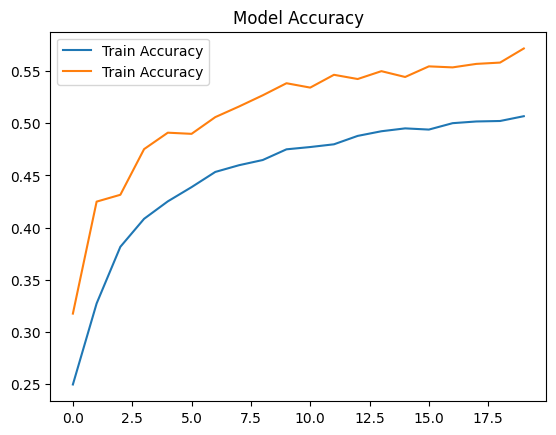

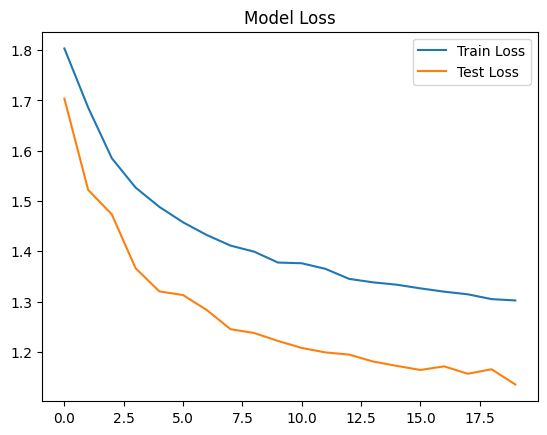

In [16]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Train Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Test Loss')
plt.legend()
plt.title("Model Loss")
plt.show()

In [17]:
model.save("emotion_model.h5")

In [18]:
!pip install opencv-python
!pip install cvzone

  Preparing metadata (setup.py) ... done
  Created wheel for cvzone: filename=cvzone-1.6.1-py3-none-any.whl size=26298 sha256=a9bd65989725a7a3f49b54dfee0ff4f86c05bfa1fc750b1c24db1baeea147037
  Stored in directory: /root/.cache/pip/wheels/5d/21/e8/3147ae88d44e27f06e0175d337a7673c70fb957202cbbe2034
Successfully built cvzone


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [20]:
model = load_model("emotion_model.h5")

In [21]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [22]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [23]:
emotion_labels = list(train_data.class_indices.keys())
print("Emotion Classes:", emotion_labels)

Emotion Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [24]:
emotion_labels = ['Angry','Disgust','Fear','Happy','Sad','Surprise','Neutral']

In [76]:
from google.colab import files
uploaded = files.upload()

Saving PrivateTest_1221822.jpg to PrivateTest_1221822.jpg


False
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted Emotion: Angry
Confidence: 55.26%


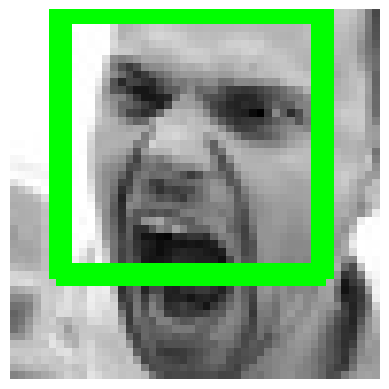

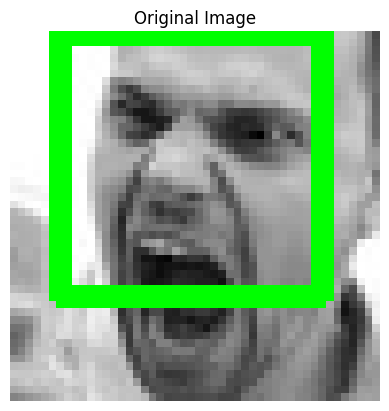

In [77]:
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=3,
    minSize=(30, 30)
)
print(face_cascade.empty())
if len(faces) == 0:
    print("No face detected")
else:
    for (x, y, w, h) in faces:
        face = gray[y:y+h, x:x+w]
        face = cv2.resize(face, (48, 48))
        face = face / 255.0
        face = np.reshape(face, (1, 48, 48, 1))

        prediction = model.predict(face)
        predicted_index = np.argmax(prediction)
        emotion = emotion_labels[predicted_index]

        # ✅ PRINT EMOTION CLEARLY
        print("Predicted Emotion:", emotion)

        # ✅ Print confidence
        confidence = prediction[0][predicted_index] * 100
        print("Confidence: {:.2f}%".format(confidence))

        # Draw on image
        cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(img, emotion, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1,
                    (0,255,0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()


In [78]:
from google.colab.patches import cv2_imshow
from IPython.display import Javascript
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Capture';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});
          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);
          stream.getVideoTracks()[0].stop();
          div.remove();
          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

<IPython.core.display.Javascript object>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


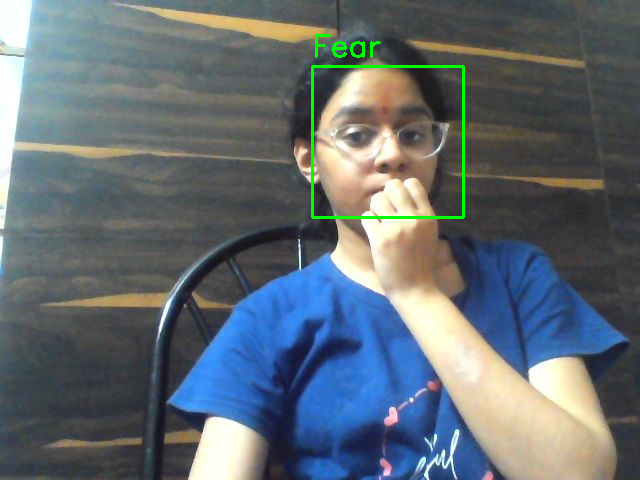

In [80]:
filename = take_photo()

img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    face = gray[y:y+h, x:x+w]
    face = cv2.resize(face, (48, 48))
    face = face / 255.0
    face = np.reshape(face, (1, 48, 48, 1))

    prediction = model.predict(face)
    emotion = emotion_labels[np.argmax(prediction)]

    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(img, emotion, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1,
                (0,255,0), 2)

cv2_imshow(img)